# 04 — Feature Engineering: CTR & Impressions (Yusuf)
**Tujuan:** Membuat fitur Click-Through Rate dan efisiensi tayangan YouTube.  
**Output:** `data/processed/features_ctr.csv`  
**Digunakan oleh:** M1-Regression, M3-Anomaly, M4-RootCause, M5-Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [ ]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/cleaned/abis_cleaning.csv')
df = df.drop_duplicates(subset=['video_id'], keep='first').reset_index(drop=True)

df['views']       = df['penayangan_tak_dilewati']
df['impressions'] = df['tayangan']
df['ctr_pct']     = df['rasio_klik_tayang_dari_tayangan']  # already in %

print(f"Shape: {df.shape}")
print(f"Missing - impressions: {df['impressions'].isnull().sum()}, ctr: {df['ctr_pct'].isnull().sum()}")
print(df[['views','impressions','ctr_pct']].describe().round(3))

Shape: (2355, 51)
Missing - impressions: 0, ctr: 0
             views   impressions   ctr_pct
count     2355.000  2.355000e+03  2355.000
mean     42805.183  2.861561e+05    12.771
std      95498.311  6.903861e+05     3.970
min         19.000  6.900000e+01     0.870
25%       4915.000  2.678450e+04    10.350
50%      12755.000  7.813800e+04    12.310
75%      37527.000  2.437055e+05    14.580
max    1515626.000  1.301034e+07    30.590


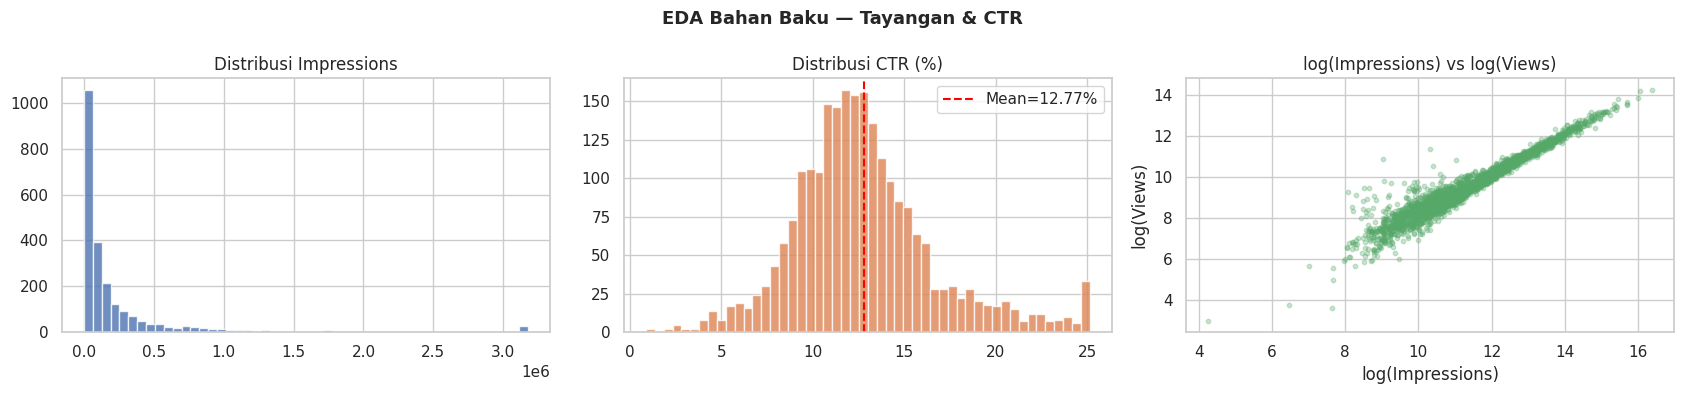

In [ ]:
# ── 2. EDA BAHAN BAKU ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('EDA Bahan Baku — Tayangan & CTR', fontsize=13, fontweight='bold')

axes[0].hist(df['impressions'].clip(0, df['impressions'].quantile(0.99)), bins=50,
             color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Impressions')

axes[1].hist(df['ctr_pct'].clip(0, df['ctr_pct'].quantile(0.99)), bins=50,
             color='#DD8452', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi CTR (%)')
axes[1].axvline(df['ctr_pct'].mean(), color='red', linestyle='--', label=f"Mean={df['ctr_pct'].mean():.2f}%")
axes[1].legend()

axes[2].scatter(np.log1p(df['impressions']), np.log1p(df['views']),
                alpha=0.3, s=10, color='#55A868')
axes[2].set_title('log(Impressions) vs log(Views)')
axes[2].set_xlabel('log(Impressions)'); axes[2].set_ylabel('log(Views)')

plt.tight_layout()
plt.show()

In [ ]:
# ── 3. FEATURE COMPUTATION ───────────────────────────────────────────────────
EPS = 1

# Konversi & normalisasi CTR
df['ctr_normalized']       = df['ctr_pct'] / 100                        # 0-1 scale
df['impression_to_view_rate'] = df['views'] / (df['impressions'] + EPS) # seberapa banyak view per impresi

# Compound metric: efisiensi CTR × konversi impresi ke view
df['ctr_impression_score']    = df['ctr_normalized'] * df['impression_to_view_rate']

# CTR expected vs actual
channel_avg_ctr = df['ctr_normalized'].mean()
df['ctr_vs_channel_avg']      = df['ctr_normalized'] / (channel_avg_ctr + EPS/100)

# Log transform impressions (untuk model linear)
df['impressions_log']         = np.log1p(df['impressions'])

# Categorical: Low/Mid/High CTR
df['ctr_category'] = pd.cut(
    df['ctr_pct'],
    bins=[0, 3, 7, float('inf')],
    labels=[0, 1, 2],   # 0=Low, 1=Mid, 2=High
    include_lowest=True
).astype(int)

print("CTR features computed ✓")
print(df['ctr_category'].value_counts().sort_index().rename({0:'Low',1:'Mid',2:'High'}))
df[['ctr_normalized','impression_to_view_rate','ctr_impression_score']].describe().round(4)

CTR features computed ✓
ctr_category
Low        9
Mid      100
High    2246
Name: count, dtype: int64


,ctr_normalized,impression_to_view_rate,ctr_impression_score
count,2355.0000,2355.0000,2355.0000
mean,0.1277,0.1852,0.0240
std,0.0397,0.2017,0.0246
min,0.0087,0.0179,0.0002
25%,0.1035,0.1325,0.0142
50%,0.1231,0.1535,0.0192
75%,0.1458,0.1884,0.0271
max,0.3059,6.1457,0.9212


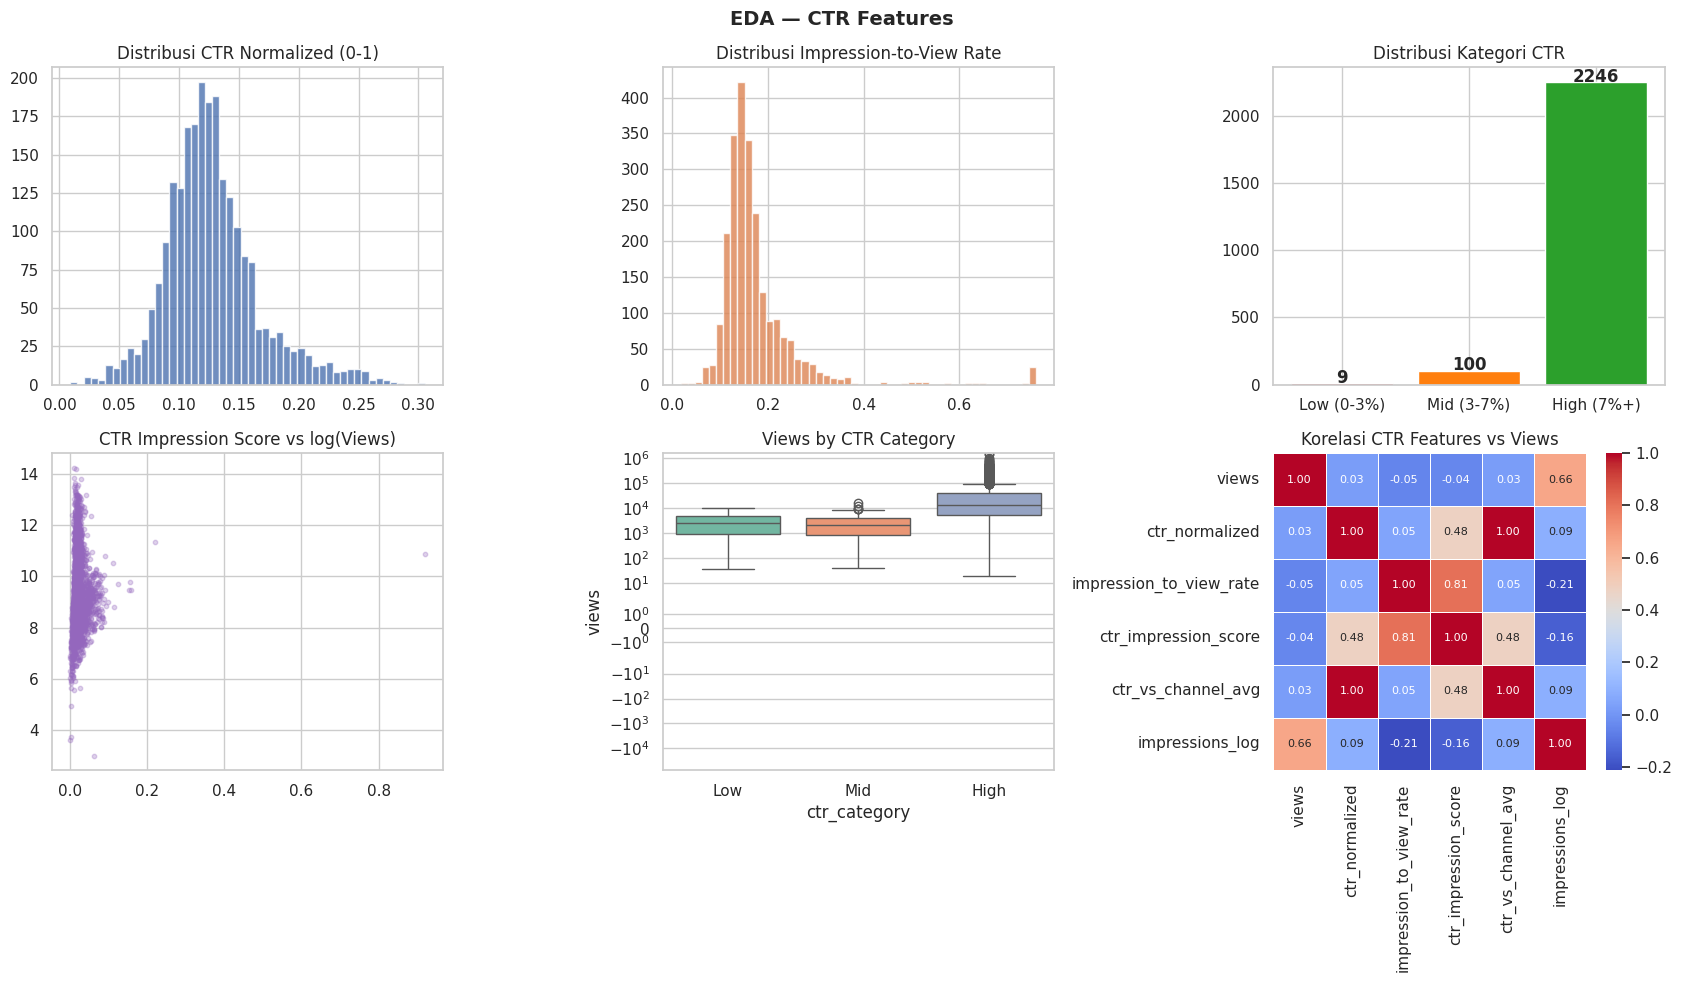

In [ ]:
# ── 4. EDA FITUR CTR ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — CTR Features', fontsize=14, fontweight='bold')

# (A) CTR distribution
axes[0][0].hist(df['ctr_normalized'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0][0].set_title('Distribusi CTR Normalized (0-1)')

# (B) Impression-to-view rate
axes[0][1].hist(df['impression_to_view_rate'].clip(0, df['impression_to_view_rate'].quantile(0.99)),
                bins=50, color='#DD8452', edgecolor='white', alpha=0.8)
axes[0][1].set_title('Distribusi Impression-to-View Rate')

# (C) CTR category bar
cat_counts = df['ctr_category'].value_counts().sort_index()
axes[0][2].bar(['Low (0-3%)','Mid (3-7%)','High (7%+)'], cat_counts.values,
               color=['#d62728','#ff7f0e','#2ca02c'], edgecolor='white')
axes[0][2].set_title('Distribusi Kategori CTR')
for i, v in enumerate(cat_counts.values):
    axes[0][2].text(i, v+5, f'{v}', ha='center', fontweight='bold')

# (D) CTR score vs views
axes[1][0].scatter(df['ctr_impression_score'], np.log1p(df['views']),
                   alpha=0.3, s=10, color='#9467BD')
axes[1][0].set_title('CTR Impression Score vs log(Views)')

# (E) CTR category vs views
sns.boxplot(data=df, x='ctr_category', y='views', palette='Set2', ax=axes[1][1])
axes[1][1].set_yscale('symlog')
axes[1][1].set_title('Views by CTR Category')
axes[1][1].set_xticklabels(['Low','Mid','High'])

# (F) Correlation
feat = ['views','ctr_normalized','impression_to_view_rate','ctr_impression_score',
        'ctr_vs_channel_avg','impressions_log']
corr = df[feat].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1][2], linewidths=0.5, annot_kws={'size':8})
axes[1][2].set_title('Korelasi CTR Features vs Views')

plt.tight_layout()
plt.show()

In [ ]:
# ── 5. VALIDASI & EXPORT ─────────────────────────────────────────────────────
ctr_cols = [
    'video_id','impression_to_view_rate','ctr_normalized',
    'ctr_impression_score','ctr_vs_channel_avg','impressions_log','ctr_category'
]
df_out = df[ctr_cols].copy()
df_out = df_out.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df_out.shape} | Nulls: {df_out.isnull().sum().sum()}")
display(df_out.head(3))

import os
output_path = '../../data/processed/features_ctr.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False)
print(f"\n✅ Tersimpan: {output_path}")

Shape: (2355, 7) | Nulls: 0


,video_id,impression_to_view_rate,ctr_normalized,ctr_impression_score,ctr_vs_channel_avg,impressions_log,ctr_category
0,jkL6Ii5d4hI,0.135947,0.1189,0.016164,0.863407,14.981516,2
1,mIeRGD4KT-A,0.120665,0.1064,0.012839,0.772636,14.961206,2
2,XCRg3dGQqd8,0.131765,0.1072,0.014125,0.778446,14.788698,2



✅ Tersimpan: ../../data/processed/features_ctr.csv
